In [1]:
from dataclasses import dataclass
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.patches import Rectangle


@dataclass
class Instrument:
    """Instrument data container."""
    ID: str
    energy_res: float   # [eV]
    fov: float          # [sr]
    psla: float         # [arcmin]

@dataclass
class InstrBox:
    """Plot instrument box data container."""
    ID: str
    xy: tuple[float, float]
    width: float
    height: float
    kwargs: dict

def get_fontscale(figsize: Optional[tuple[float, float]]) -> float:
    alpha = np.array(figsize) / np.array([12, 10]) if figsize is not None else np.ones(2)
    # alpha = np.sqrt(np.square(alpha).sum())
    alpha = alpha.mean()
    return alpha

def make_fig_layout(
    ax: Axes,
    xlims: Optional[tuple],
    ylims: Optional[tuple],
    xlabel: str,
    ylabel: str,
    options: Optional[dict],
) -> tuple[Figure, Axes]:
    ax.set_xscale('linear'); ax.set_yscale('log')
    ax.set_xlim(*xlims); ax.set_ylim(*ylims)

    ax.set_xlabel(xlabel=xlabel, fontsize=options.get('xlbl_fs', 'medium'))
    ax.set_ylabel(ylabel=ylabel, fontsize=options.get('ylbl_fs', 'medium'))

    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(
        which='both', direction='in', width=1.5,
        length=4 if 'major' else 2.5,
        labelsize=options.get('ticks_lbl_size', 'medium')
    )
    ax.grid(True, which='both', linewidth=0.15, alpha=0.9)
    return




def plot_FoV_vs_PSLA(
    instruments: list[Instrument],
    trg_instr: Optional[InstrBox | list[InstrBox]] = None,
    save_to: Optional[str] = None,
    save_kws: Optional[dict] = None,
    options: Optional[dict] = None,
    **fig_kws,
) -> None:
    options = options or {}
        
    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    ax.set_title(
        'High-Energy Transient Monitors: FoV vs Localisation Accuracy',
        fontsize=options.get('title_fs', 'large'),
        pad=options.get('title_pad', 6)
    )
    alpha = options.get('instr_lbl_fontscale', None)
    alpha = alpha if alpha is not None else get_fontscale(fig_kws.get('figsize', None))

    for instr in instruments:
        loc = np.array([instr.fov, instr.psla])
        pnt = ax.scatter(*loc, **options.get('scatter_kws', {}))
        
        if trg_instr is not None:
            trg_instr_ = [trg_instr] if isinstance(trg_instr, InstrBox) else trg_instr
            for trg in trg_instr_:
                if trg.ID.lower() == instr.ID.lower():
                    ax.add_patch(
                        Rectangle(
                            xy=trg.xy, width=trg.width, height=trg.height,
                            edgecolor=tuple(pnt.get_facecolor()[0]), **trg.kwargs,
                        )
                    )
        
        is_arcmin = instr.psla < 60
        txt_res = f'{instr.psla} arcmin' if is_arcmin else f'<{instr.psla // 60} deg'
        get_ID_offset = options.get('get_ID_offset', lambda x: np.array([-0.2, x / 3.5]))
        get_sub_offset = options.get('get_subID_offset', lambda x: np.array([-0.2, x / 7.5]))
        
        txt_factory = {'color': tuple(pnt.get_facecolor()[0]), 'fontweight': 'bold'}
        ax.text(
            *(loc + get_ID_offset(instr.psla)), f'{instr.ID}',
            fontsize=alpha * options.get('ID_fs', 11), **txt_factory
        )
        ax.text(
            *(loc + get_sub_offset(instr.psla)), f'({txt_res}, {instr.fov} sr)',
            fontsize=alpha * options.get('subID_fs', 7), **txt_factory
        )

    make_fig_layout(ax, (-0.5, 9), (0.5, 2e3), 'FoV (solid angle) [sr]', 'Localisation Accuracy [arcmin]', options)

    if save_to is not None:
        save_kws = save_kws or {}
        fig.savefig(save_to, **save_kws)
    plt.show()

    return

def plot_FoV_vs_EnergyRes(
    instruments: list[Instrument],
    trg_instr: Optional[InstrBox | list[InstrBox]] = None,
    save_to: Optional[str] = None,
    save_kws: Optional[dict] = None,
    options: Optional[dict] = None,
    **fig_kws,
) -> None:
    options = options or {}
    
    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    ax.set_title(
        'High-Energy Transient Monitors: FoV vs Energy Resolution',
        fontsize=options.get('title_fs', 'large'),
        pad=options.get('title_pad', 6)
    )
    alpha = options.get('instr_lbl_fontscale', None)
    alpha = alpha if alpha is not None else get_fontscale(fig_kws.get('figsize', None))

    for instr in instruments:
        loc = np.array([instr.fov, instr.energy_res])
        pnt = ax.scatter(*loc, **options.get('scatter_kws', {}))
        
        if trg_instr is not None:
            trg_instr_ = [trg_instr] if isinstance(trg_instr, InstrBox) else trg_instr
            for trg in trg_instr_:
                if trg.ID.lower() == instr.ID.lower():
                    ax.add_patch(
                        Rectangle(
                            xy=trg.xy, width=trg.width, height=trg.height,
                            edgecolor=tuple(pnt.get_facecolor()[0]), **trg.kwargs,
                        )
                    )
        
        is_eV = instr.energy_res < 1000
        txt_res = f'{instr.energy_res} eV' if is_eV else f'{instr.energy_res // 1000} keV'
        get_ID_offset = options.get('get_ID_offset', lambda e: np.array([-0.2, e / 4.5]))
        get_sub_offset = options.get('get_subID_offset', lambda e: np.array([-0.2, e / 9]))
        
        txt_factory = {'color': tuple(pnt.get_facecolor()[0]), 'fontweight': 'bold'}
        ax.text(*(loc + get_ID_offset(instr.energy_res)), f'{instr.ID}', fontsize=alpha * options.get('ID_fs', 11), **txt_factory)
        ax.text(*(loc + get_sub_offset(instr.energy_res)), f'({txt_res})', fontsize=alpha * options.get('subID_fs', 7), **txt_factory)

    make_fig_layout(ax, (-0.5, 9), (None, 1e5), 'FoV (solid angle) [sr]', 'Energy Resolution [eV]', options)

    if save_to is not None:
        save_kws = save_kws or {}
        fig.savefig(save_to, **save_kws)
    plt.show()

    return

In [2]:
instrs = [
    Instrument('LEM-X', energy_res=350, fov=5, psla=1),
    # Instrument('GECO', energy_res=350, fov=6.3, psla=1),

    Instrument('MAXI/GSC', energy_res=1300, fov=0.15, psla=12),
    Instrument('MAXI/SSC', energy_res=145, fov=0.08, psla=6),
    Instrument('INTEGRAL/IBIS', energy_res=8000, fov=0.3, psla=3),
    Instrument('EinsteinProbe/WXT', energy_res=170, fov=1.1, psla=5),
    Instrument('Swift/BAT', energy_res=5000, fov=1.4, psla=4),
    Instrument('SVOM/ECLAIRs', energy_res=1300, fov=2, psla=12),
    Instrument('GECAM', energy_res=35000, fov=6, psla=120),
    Instrument('Fermi/GBM', energy_res=60000, fov=8, psla=900),
]

In [3]:
fig_width = 10

options = dict(
    title_fs=16,
    title_pad=10,
    xlbl_fs=14,
    ylbl_fs=14,
    ticks_lbl_size=14,

    get_ID_offset=lambda x: np.array([-0.25, x / 3]),
    get_subID_offset=lambda x: np.array([-0.25, x / 9]),

    ID_fs=16,
    subID_fs=13,
    scatter_kws=dict(s=70),
)

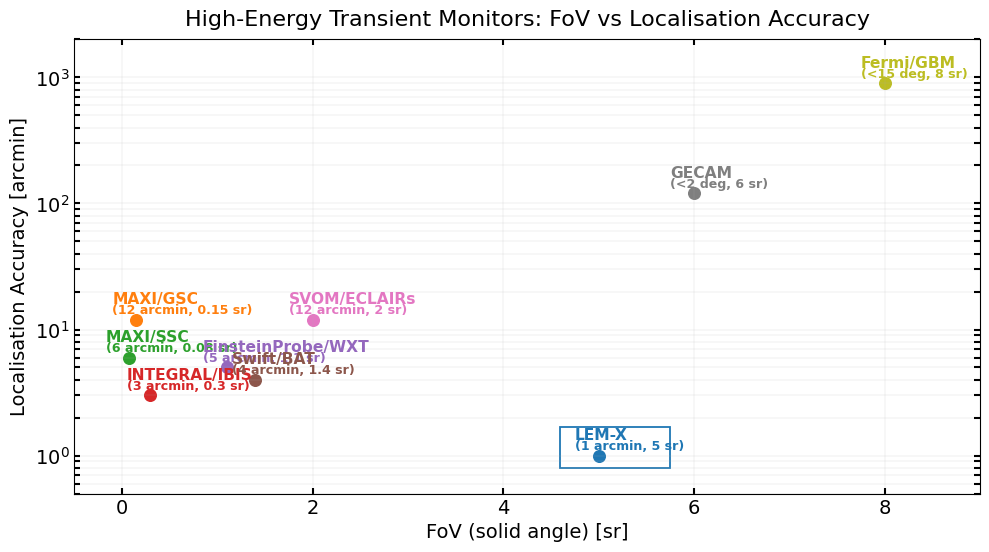

In [4]:
trg_instrs = InstrBox(ID='LEM-X', xy=(4.6, 0.8), width=1.15, height=0.9, kwargs=dict(linewidth=1.3, facecolor='none'))
# trg_instrs = InstrBox(ID='GECO', xy=(6, 0.8), width=1.15, height=0.9, kwargs=dict(linewidth=1.3, facecolor='none'))

plot_FoV_vs_PSLA(
    instrs,
    figsize=(fig_width, 9 / 16 * fig_width),
    trg_instr=trg_instrs,
    save_to=r'/mnt/c/Users/Edoardo Giancarli/Desktop/lem-x_FoV_vs_PSLA.svg',
    # save_to='/mnt/d/PhD_AASS/Coding/Images_fits/lem-x_FoV_vs_PSLA.svg',
    # save_to='/mnt/d/PhD_AASS/Coding/Images_fits/geco_FoV_vs_PSLA.svg',
    options=options,
)

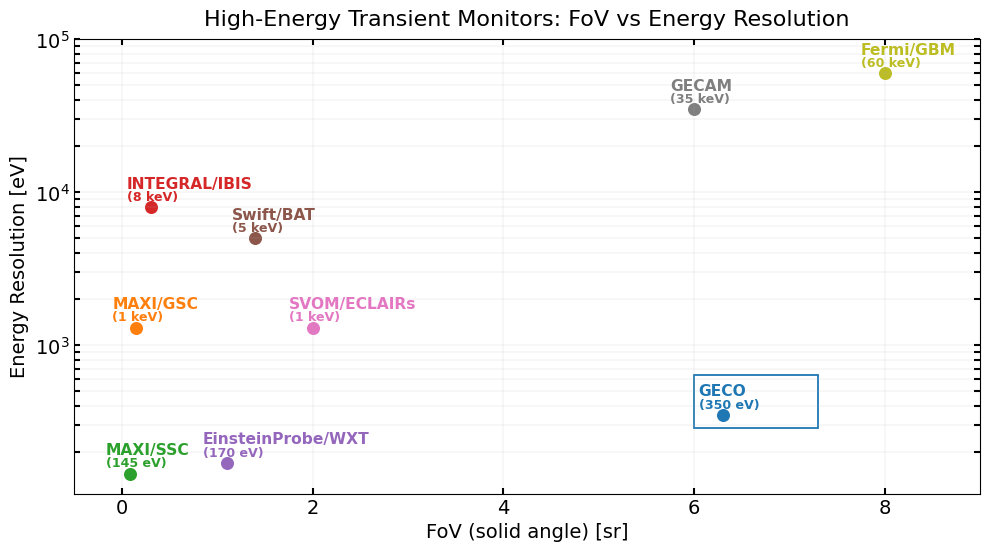

In [15]:
# trg_instrs = InstrBox(ID='LEM-X', xy=(4.4, 290), width=1.3, height=350, kwargs=dict(linewidth=1.3, facecolor='none'))
trg_instrs = InstrBox(ID='GECO', xy=(6, 290), width=1.3, height=350, kwargs=dict(linewidth=1.3, facecolor='none'))

plot_FoV_vs_EnergyRes(
    instrs,
    figsize=(fig_width, 9 / 16 * fig_width),
    trg_instr=trg_instrs,
    save_to=r'/mnt/c/Users/Edoardo Giancarli/Desktop/geco_FoV_vs_EnergyRes.svg',
    # save_to='/mnt/d/PhD_AASS/Coding/Images_fits/lem-x_FoV_vs_EnergyRes.svg',
    # save_to='/mnt/d/PhD_AASS/Coding/Images_fits/geco_FoV_vs_EnergyRes.svg',
    options=options,
)